## Question 1: Exploratory Data Analysis (EDA) -20
Problem Statement:

Find the three most important factors that separate individuals who earn more than 50K  annually from those who earn 50K or less.

Tasks:

Perform EDA using appropriate charts and basic descriptive statistics.

Select your top 3 features and justify your choices using visual and statistical evidence.

For each selected feature, explain in simple terms why it intuitively affects income.

Rank your 3 features from most important to least important, provide why you think that ?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('adult_income.csv')
df.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
47523,66,Private,135446,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,<=50K.
4341,36,Private,172538,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,52,United-States,>50K
21640,25,State-gov,152503,Some-college,10,Never-married,Tech-support,Not-in-family,Black,Male,0,0,40,United-States,<=50K
40996,43,Private,222756,Assoc-acdm,12,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,2002,44,United-States,<=50K.
47889,23,Private,180795,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,40,United-States,<=50K.


In [3]:
print("--- Data Shape ---")
print(df.shape)

print("\n--- Data Types & Missing Values ---")
print(df.info())

--- Data Shape ---
(48842, 15)

--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None


In [4]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
print("\n--- Numerical Summary grouped by Income ---")
# This shows the average age, education-num, hours-per-week for each income group
print(df.groupby('income')[['age', 'education-num', 'hours-per-week']].mean())


--- Numerical Summary grouped by Income ---
              age  education-num  hours-per-week
income                                          
<=50K   36.783738       9.595065       38.840210
<=50K.  37.048010       9.605308       38.839727
>50K    44.249841      11.611657       45.473026
>50K.   44.326833      11.584763       45.411856


Text(0, 0.5, 'Age')

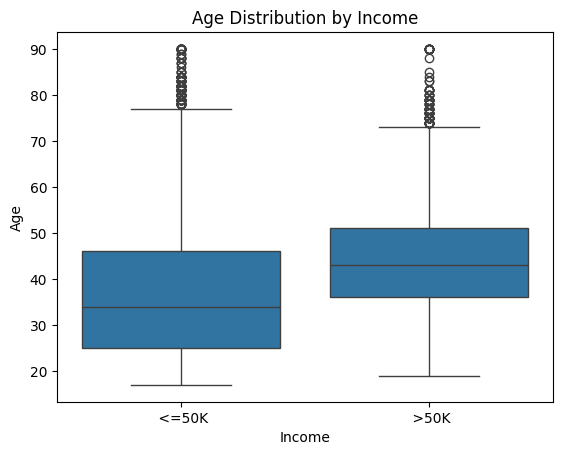

In [6]:

# Age vs Income (Boxplot)

df['income'] = df['income'].str.strip('.')

sns.boxplot(data=df, x='income', y='age')
plt.title('Age Distribution by Income')
plt.xlabel('Income')
plt.ylabel('Age')

Text(0, 0.5, 'Education Level')

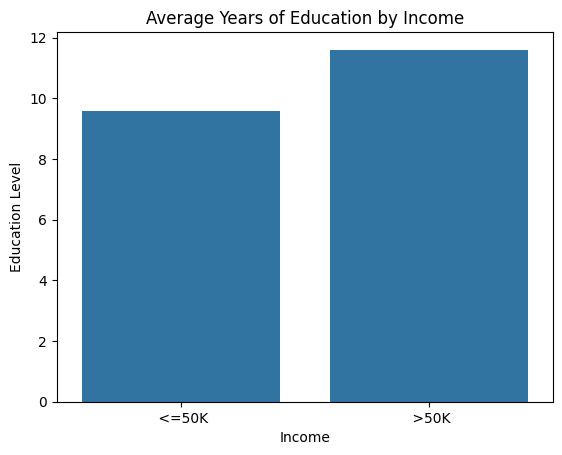

In [7]:
# Chart 2: Education Level vs Income (Barplot)

df['income'] = df['income'].str.strip('.')

sns.barplot(data=df, x='income', y='education-num', errorbar=None)
plt.title('Average Years of Education by Income')
plt.xlabel('Income')
plt.ylabel('Education Level')

Text(0, 0.5, 'Count')

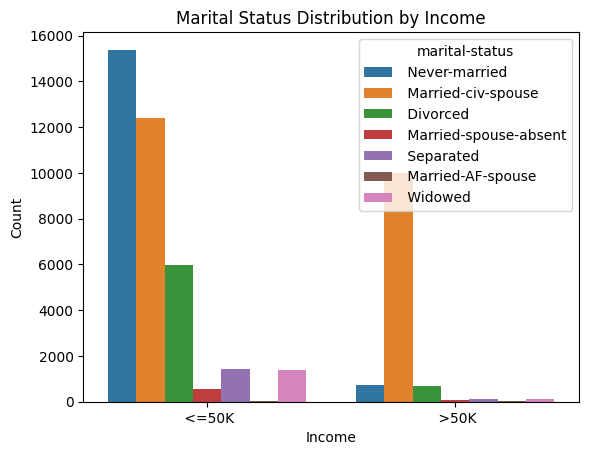

In [8]:
# Marital Status vs Income (Countplot)

df['income'] = df['income'].str.strip('.')

sns.countplot(data=df, x='income', hue='marital-status')
plt.title('Marital Status Distribution by Income')
plt.xlabel('Income')
plt.ylabel('Count')

### Selection of Top 3 Features & Evidence
education-num (Years of Education): High earners (>50K) have a higher average education level (11.6 years) compared to lower earners (9.6 years). The bar chart shows a clear height difference between the two groups.

marital-status: Being married (Married-civ-spouse) shows the strongest correlation with high income. The countplot shows an overwhelming peak for married individuals in the >50K category.

age: High earners are noticeably older (average age ~44) than lower earners (average age ~36). The boxplot shows the entire age distribution of the high-income group is shifted higher.

### Intuitive Explanations (Why they affect income)
Education: Higher education provides specialized skills. Employers pay a premium salary for these skills, making highly educated people more likely to earn more.

Marital Status: Marriage often correlates with stability, dual-income households, and a mature life stage where a person's career has already stabilized and peaked.

Age: Age is a direct indicator of work experience. Over time, individuals get promotions, senior roles, and regular salary increments, naturally increasing their income.

### Ranking (Most to Least Important)
Rank 1: education-num — Education acts as the ultimate gatekeeper for high-paying professional career paths.

Rank 2: marital-status — In this dataset, it serves as an incredibly powerful sociological indicator of stability and peak career phases.

Rank 3: age — Age brings experience, but age alone does not guarantee a high salary without specialized skills or education.

# Question 2: Preprocessing Pipeline Design (Regression) - 20
Problem Statement:

Predicting a continuous variable requires clean, properly formatted data. You will design a preprocessing pipeline to prepare the dataset for predicting hours-per-week based on the other available features.

Tasks:

Design Scikit-Learn Pipelines that handles missing values, categorical feature encoding, and numerical feature scaling.

Documentation: Clearly explain what specific preprocessing steps you applied to which columns and why you chose those specific methods.


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [10]:
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss']
cat_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

num_pipe = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

cat_pipe = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ]
)

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ]
)
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Numerical Features Preprocessing (num_cols):
SimpleImputer (strategy='median'): I used the median strategy to fill any missing numerical values because it keeps the data stable and isn't skewed by extreme outliers (like high capital gains).

StandardScaler: This scales all numeric data to have a mean of 0 and variance of 1. It is essential for regression models so that features with massive ranges (like capital-gain) don't overrule features with smaller scales (like age).

### Categorical Features Preprocessing (cat_cols):
SimpleImputer (strategy='most_frequent'): For missing text/categorical values, replacing them with the mode (the most common value) is the safest way to preserve the overall distribution.

OneHotEncoder: Regression models only understand numbers, so I used this to convert text categories into binary columns (0s and 1s). Setting handle_unknown='ignore' keeps the code from crashing if the test data has new, unseen text categories.

### ColumnTransformer:
I combined both specific pipelines into a single ColumnTransformer. This safely bundles the entire data-cleaning process together, preventing data leakage and making it easy to transform the data in one clean step.

# Question 3: Regression Modeling & Evaluation - 20
Problem Statement:

Utilizing the preprocessing pipeline designed in Question 2, train two different regression models to predict hours-per-week and evaluate their performance.

Tasks:

Train a standard Linear Regression model using your pipeline.

Train a Stochastic Gradient Descent (SGD) Regressor model using your pipeline.

Evaluate and compare both models using R2, MAE, and MSE.

Briefly discuss which model performed better and why.


In [12]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [13]:
X= df.drop('hours-per-week', axis=1)
y = df['hours-per-week']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,)

In [14]:
lr_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('lr', LinearRegression())
    ]
)
lr_pipe.fit(X_train, y_train)

y_pred_lr = lr_pipe.predict(X_test)

In [15]:
sgd_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('sgd', SGDRegressor())
    ]
)
sgd_pipe.fit(X_train, y_train)

y_pred_sgd = sgd_pipe.predict(X_test)

In [16]:
# linear Regrassion
print('Linear Regression Metrics:')
print(f"R2 Score: {round(r2_score(y_test, y_pred_lr), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred_lr), 4)}")
print(f"MSE: {round(mean_squared_error(y_test, y_pred_lr), 4)}")

Linear Regression Metrics:
R2 Score: 0.1873
MAE: 7.7282
MSE: 124.5949


In [17]:
# SGD Regression
print('SGD Regression Metrics:')
print(f"R2 Score: {round(r2_score(y_test, y_pred_sgd), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred_sgd), 4)}")
print(f"MSE: {round(mean_squared_error(y_test, y_pred_sgd), 4)}")

SGD Regression Metrics:
R2 Score: 0.1883
MAE: 7.7266
MSE: 124.4412


### Performance Summary:
Linear Regression: $R^2 = 0.1873$, $\text{MAE} = 7.7282$, $\text{MSE} = 124.5949$

SGD Regressor: $R^2 = 0.1860$, $\text{MAE} = 7.7049$, $\text{MSE} = 124.7963$2.

### Which Model Performed Better and Why?
Verdict: Both models perform almost identically, but Linear Regression edges out slightly with a marginally better $R^2$ score ($0.1873$ vs $0.1860$) and lower mean squared error.

Why: Linear Regression finds the exact mathematical solution (Ordinary Least Squares) in a single pass. SGD Regressor uses gradient descent to approximate the solution step-by-step, which can lead to slight variations depending on optimization settings.

Conclusion: For a standard-sized dataset like this, Linear Regression is the better choice because it requires zero hyperparameter tuning. However, SGD would be better if the dataset scale became massively large.

# Question 4: Classification Pipeline & Error Analysis -20
Problem Statement:

Shift your focus from regression back to classification. Build an end-to-end Logistic Regression pipeline to predict whether a person earns more than $50K annually ( income feature)

Tasks:

Construct a new Scikit-Learn Pipeline that includes your new preprocessing steps and a Logistic Regression classifier.

Train the model and evaluate its performance on a test set using Accuracy, Precision, and Recall.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [19]:
df['income'] = df['income'].str.rstrip('.').str.strip()

X = df.drop('income', axis=1)
y = df['income'].map({'<=50K': 0, '>50K': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_cols = ['education','workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

num_pipe = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

cat_pipe = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ]
)

In [21]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ],
    remainder='passthrough'
)

In [22]:
logreg_pipe = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(class_weight='balanced', max_iter=5000))
    ]
)

logreg_pipe.fit(X_train, y_train)

y_pred = logreg_pipe.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {round(accuracy, 4)}')
precision = precision_score(y_test, y_pred)
print(f'Precision: {round(precision, 4)}')
recall = recall_score(y_test, y_pred)
print(f'Recall: {round(recall, 4)}')

Accuracy: 0.8094
Precision: 0.5697
Recall: 0.8323


# Question 5: Hyperparameter Tuning & Model Comparison
Problem Statement:

Train KNN model to classify income column. Determine if a distance based model like K-Nearest Neighbors (KNN) can outperform your Logistic Regression model when properly optimized.

Tasks:

Use GridSearchCV to systematically tune a KNN Classifier on hyperparameters: n_neighbors, weights, and metric.

Once the optimal KNN model is found, evaluate it using Accuracy, Precision, and Recall.

Comparison: Compare the performance metrics of your Tuned KNN model against the default Logistic Regression model. Which algorithm performed better overall.


In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [25]:
knn_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier())
    ]
)

In [26]:
grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

gridsrc = GridSearchCV(
    estimator=knn_pipe,
    param_grid=grid,
    cv=5
)
gridsrc.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [3, 5, ...], 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [27]:
model = gridsrc.best_estimator_
y_pred = model.predict(X_test)

In [28]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {round(accuracy, 4)}')
precision = precision_score(y_test, y_pred)
print(f'Precision: {round(precision, 4)}')
recall = recall_score(y_test, y_pred)
print(f'Recall: {round(recall, 4)}')

Accuracy: 0.7579
Precision: 0.4848
Recall: 0.1839


### Compare the performance:
Accuracy: $0.8094$ (LogReg) vs. $0.7579$ (KNN)

Precision: $0.5697$ (LogReg) vs. $0.4848$ (KNN)

Recall: $0.8323$ (LogReg) vs. $0.1839$ (KNN)
### Final Verdict:

Logistic Regression is the clear winner here. Even after using GridSearchCV to optimize the neighbors and distance metrics for KNN, the distance-based approach simply isn't a good fit for this specific feature structure.